In [3]:
from koala.voronization import generate_lattice
from koala.pointsets import uniform, bluenoise
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.lattice import Lattice
from koala.graph_color import color_lattice
from koala import plotting as pl
from tqdm import tqdm
from alter_morph.lattice_utilities import add_contacts
from scipy import linalg as la

from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_m_values,
    find_spin_per_state,
    fermi_probability,
    spectral_function,
)

from copy import copy
import numpy as np
import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

Lattice(528 vertices, 1010 edges) Lattice(506 vertices, 742 edges) Lattice(519 vertices, 1002 edges)


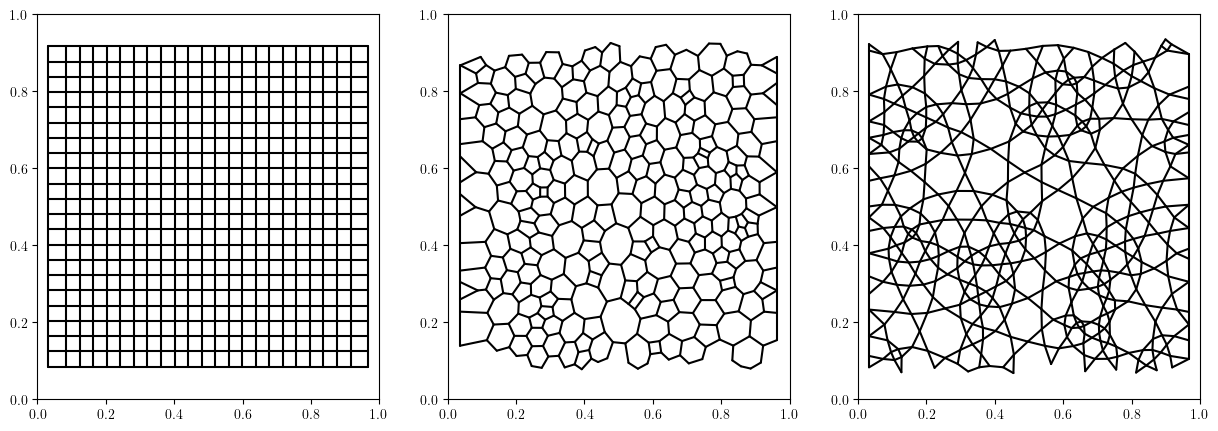

In [4]:
# generate the lattice
n_vertices = 22**2
points = uniform(n_vertices)

vor_lat = generate_lattice(uniform(n_vertices // 2))
dimerisation = gu.dimerise(vor_lat)
lattice1 = gu.lloyd_relaxation(vor_lat, 10)
lattice1 = add_contacts(lattice1, cross_edges=True)
lattice1 = gu.remove_trailing_edges(lattice1)


l2 = generate_lattice(uniform(n_vertices // 3))
l2 = gu.lloyd_relaxation(l2, 10)
exp_lat = gu.vertices_to_polygon(l2)
dimer_exp = np.zeros(exp_lat.n_edges)
dimer_exp[: l2.n_edges] = 1
lattice2 = gu.dimer_collapse(exp_lat, dimer_exp)
lattice2 = add_contacts(lattice2, cross_edges=True)

rows = np.round(np.sqrt(n_vertices)).astype(int)
lattice0 = eg.square_lattice(rows, rows)
lattice0 = add_contacts(lattice0, cross_edges=True)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
pl.plot_edges(lattice0, ax=ax[0])
pl.plot_edges(lattice1, ax=ax[1])
pl.plot_edges(lattice2, ax=ax[2])

print(lattice0, lattice1, lattice2)

In [5]:
t1 = 1
t2 = 0.1
J = 0.5
filling = 0.5

lat = lattice1
initial_m = np.zeros(lat.n_vertices) + 1.2

ham = alt_hamiltonian(lat, t1, t2, J, initial_m)
e, v = np.linalg.eigh(ham)

In [6]:
# setup initial conditions for the simulation

fermi_occupation = np.linspace(0, 1, len(e)) <= filling
n_filled_states = np.sum(fermi_occupation)
fermi_energy = e[n_filled_states - 1]

initial_derived_m = find_m_values(v, filling)
initial_average_m_per_state = find_m_per_state(v)

In [7]:
# now let's do the mean field iteration
n_iterations = 20
m_values = np.zeros((n_iterations + 1, lat.n_vertices))
m_values[0] = initial_m

prange = tqdm(range(n_iterations))
counter = 0
for n in prange:
    ham = alt_hamiltonian(lat, t1, t2, J, m_values[n])
    e, v = la.eigh(ham)
    m_values[n + 1] = find_m_values(v, filling)

    diff = np.linalg.norm(m_values[n + 1] - m_values[n])
    avg_m = np.mean(m_values[n + 1])
    prange.set_description(f"Avg:{avg_m:.2f}, diff: {diff:.6f}")

    if diff < 1e-6:
        counter += 1
        if counter > 2:
            m_values = m_values[: n + 1]
            break

Avg:1.96, diff: 0.000000:  45%|████▌     | 9/20 [00:16<00:19,  1.81s/it] 


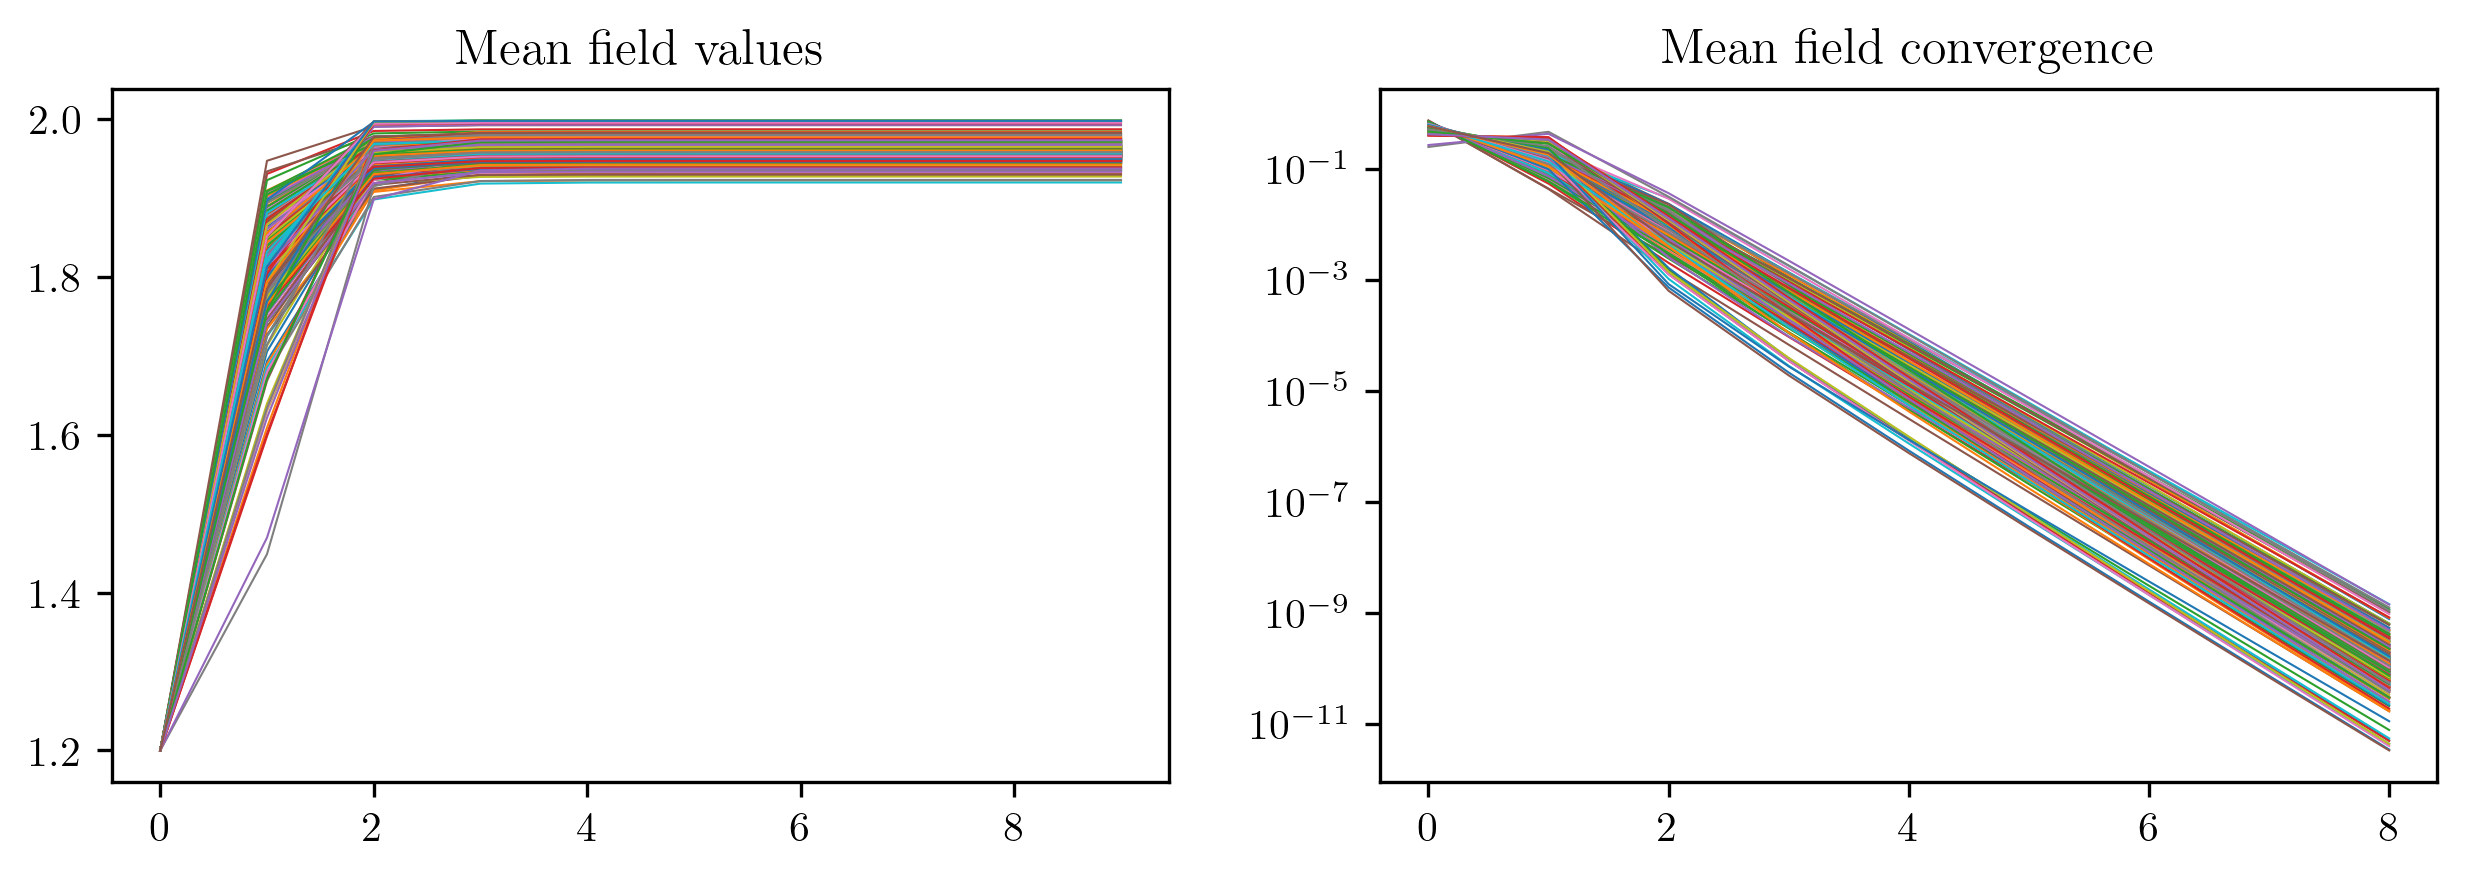

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3), dpi=300)
ax[0].plot(m_values, linewidth=0.5)

diffs = np.diff(m_values, axis=0)
ax[1].plot(np.abs(diffs), linewidth=0.5)


ax[0].set_title("Mean field values")
ax[1].set_title("Mean field convergence")
ax[1].set_yscale("log")
plt.show()

In [9]:
fermi_occupation = np.linspace(0, 1, len(e)) <= filling
n_filled_states = np.sum(fermi_occupation)
fermi_energy = e[n_filled_states - 1]

real_space_occupation = fermi_occupation[None, :] * (v * v.conj())
average_occupation = np.sum(real_space_occupation, axis=1)
average_occupation = (
    average_occupation[::4]
    + average_occupation[1::4]
    + average_occupation[2::4]
    + average_occupation[3::4]
)

ipr = np.sum(v**4, axis=0)

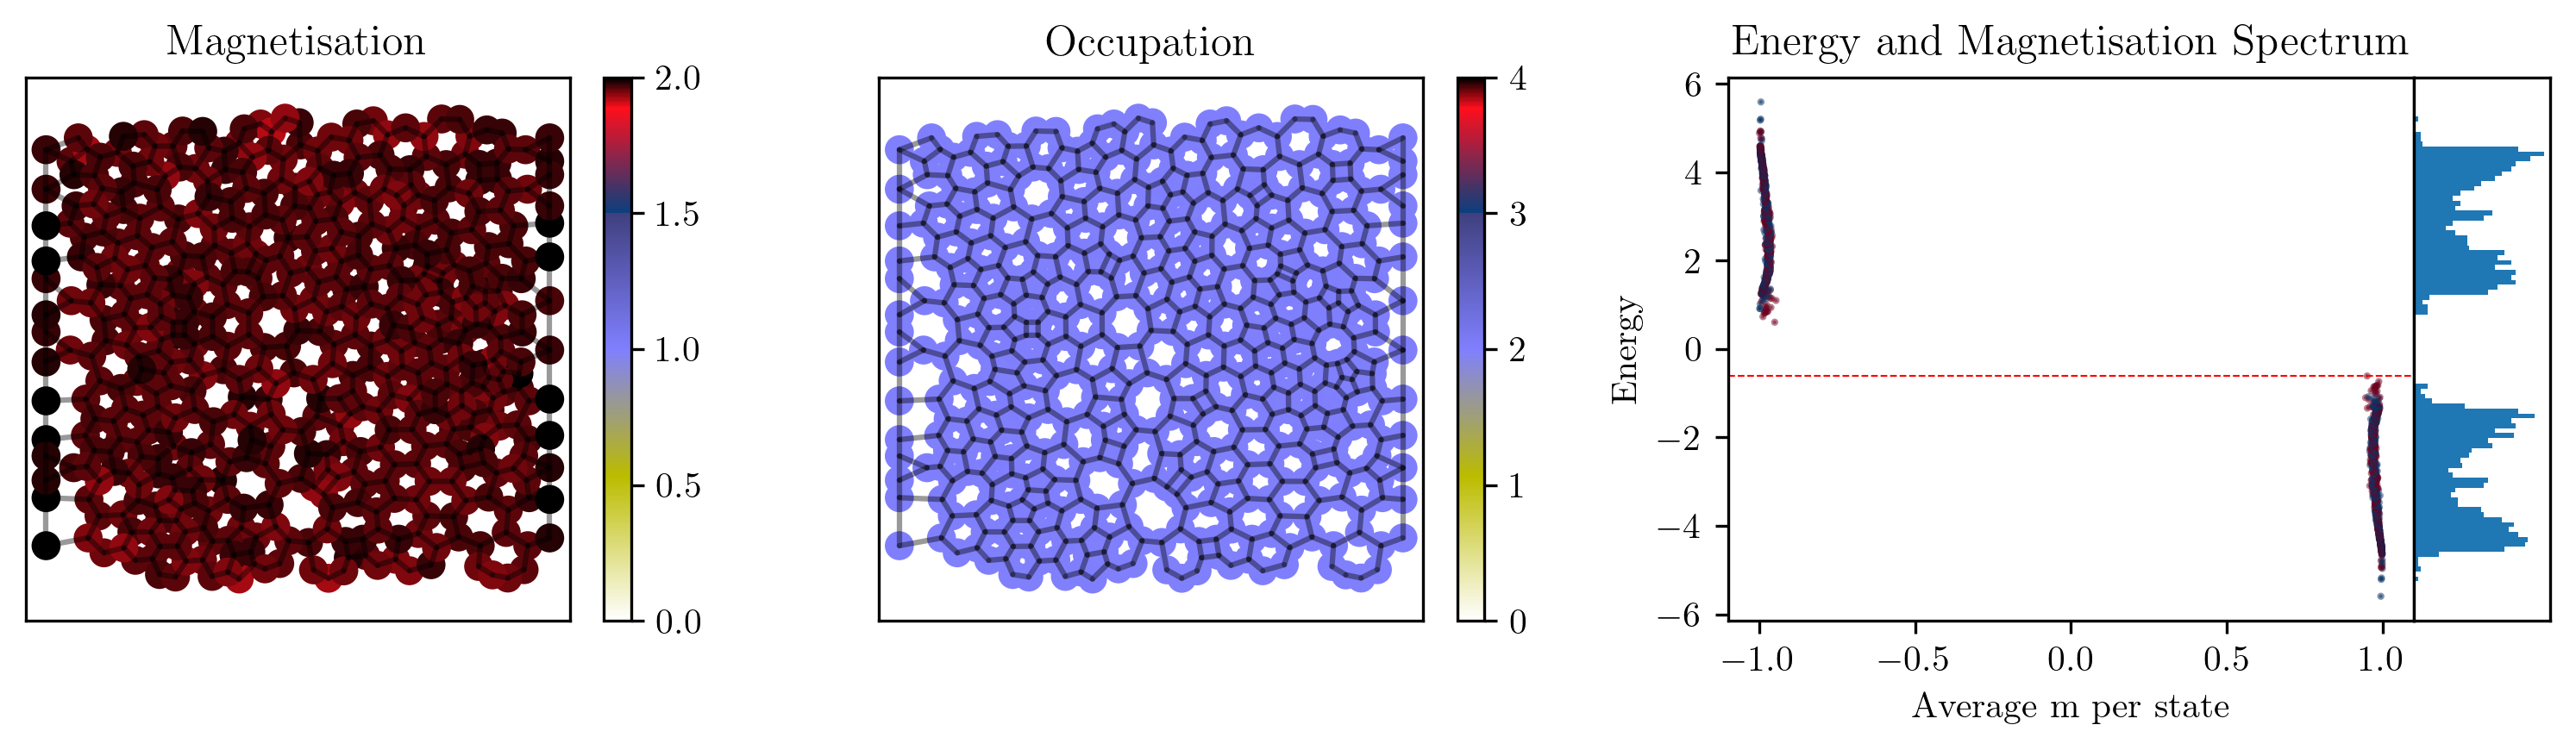

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)


average_m_per_state = find_m_per_state(v)
average_spin_per_state = find_spin_per_state(v)

m_values_out = m_values[-1]

vertices = lat.vertices.positions
pl.plot_edges(lat, ax=ax[0], alpha=0.4)
im = ax[0].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=m_values_out,
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=2,
)
plt.colorbar(im, ax=ax[0])
ax[0].set_aspect("equal")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title("Magnetisation")


pl.plot_edges(lat, ax=ax[1], alpha=0.4)
im = ax[1].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=average_occupation,
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=4,
)
plt.colorbar(im, ax=ax[1])
ax[1].set_aspect("equal")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title("Occupation")

im = ax[2].scatter(
    average_m_per_state, e, s=1, c=average_spin_per_state, cmap="RdBu", alpha=0.5
)
ax[2].set_xlabel("Average m per state")
ax[2].set_ylabel("Energy")


ax_histy = ax[2].inset_axes([1.0, 0, 0.2, 1])
ax[2].axhline(fermi_energy, color="r", linestyle="--", linewidth=0.5)
ax[2].set_title("Energy and Magnetisation Spectrum")
# move ticks to left
ax[2].yaxis.tick_left()
# plt.colorbar(im, ax=ax[2], label="IPR",

ax_histy.hist(e, bins=100, orientation="horizontal")
ax_histy.set_xticks([])
ax_histy.set_yticks([])

plt.tight_layout()

In [11]:
# find the spectral function
# def kx_ky_states(lattice, k_cutoff=30):
#     positions = lattice.vertices.positions
#     k_values = 2 * np.pi * np.arange(-k_cutoff, k_cutoff)

#     kx, ky = np.meshgrid(k_values, k_values)
#     kx = kx.flatten()
#     ky = ky.flatten()

#     rotation_matrix = np.exp(
#         1j * (kx[:, None] * positions[:, 0] + ky[:, None] * positions[:, 1])
#     )

#     # print(rotation_matrix.shape)

#     return rotation_matrix, kx, ky


omega = fermi_energy - 2
broadening = 0.1
specs = [
    spectral_function(
        lat, e, v, omega, local_projector=np.array([1, 0, 0, 0]), eta=broadening, n_k=50
    ),
    spectral_function(
        lat, e, v, omega, local_projector=np.array([0, 1, 0, 0]), eta=broadening, n_k=50
    ),
    spectral_function(
        lat, e, v, omega, local_projector=np.array([0, 0, 1, 0]), eta=broadening, n_k=50
    ),
    spectral_function(
        lat, e, v, omega, local_projector=np.array([0, 0, 0, 1]), eta=broadening, n_k=50
    ),
]

Text(0.5, 1.0, 'Spin down-Y spectral function')

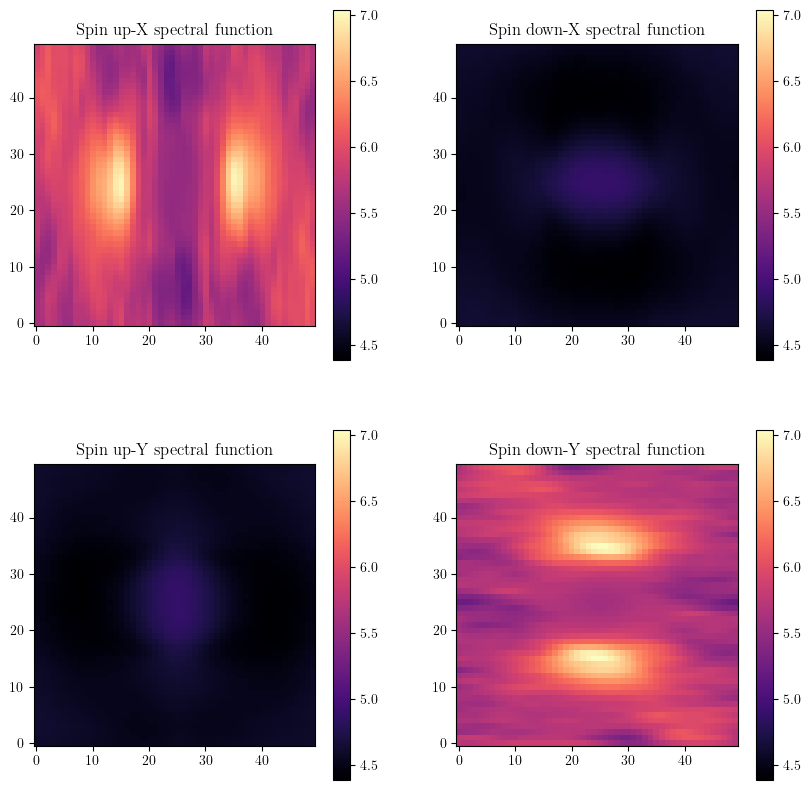

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
k_limits = 25

kx = np.arange(-k_limits, k_limits)
ky = np.arange(-k_limits, k_limits)

log_specs = np.array([np.log(np.abs(spec)) for spec in specs])

cmin = np.min(log_specs)
cmax = np.max(log_specs)

for n, a in enumerate(ax.flatten()):
    im = a.imshow(
        log_specs[n],
        cmap="magma",
        origin="lower",
        vmin=cmin,
        vmax=cmax,
    )
    # add colorbar
    plt.colorbar(im, ax=a)

# ax[0].imshow(
#     np.log(np.abs(spec1)),
#     cmap="magma",
#     origin="lower",
#     vmin=np.log(cmin),
#     vmax=np.log(cmax),
# )
# ax[1].imshow(
#     np.log(np.abs(spec2)),
#     cmap="magma",
#     origin="lower",
#     vmin=np.log(cmin),
#     vmax=np.log(cmax),
# )

# # set units in k space
# ax[0].set_xticks(np.arange(0, 26, 5))
# ax[0].set_xticklabels(kx[::5])
# ax[0].set_yticks(np.arange(0, 26, 5))
# ax[0].set_yticklabels(ky[::5])
# ax[1].set_xticks(np.arange(0, 26, 5))
# ax[1].set_xticklabels(kx[::5])
# ax[1].set_yticks(np.arange(0, 26, 5))
# ax[1].set_yticklabels(ky[::5])

# ax[0].axhline(13, color="r", linestyle="--", linewidth=0.5)
# ax[0].axvline(13, color="r", linestyle="--", linewidth=0.5)
# ax[1].axhline(13, color="r", linestyle="--", linewidth=0.5)
# ax[1].axvline(13, color="r", linestyle="--", linewidth=0.5)


ax[0, 0].set_title("Spin up-X spectral function")
ax[0, 1].set_title("Spin down-X spectral function")
ax[1, 0].set_title("Spin up-Y spectral function")
ax[1, 1].set_title("Spin down-Y spectral function")